# Award Value Prediction —

Models:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient-Boosted Trees (GBT)

Temporal evaluation:
- **Train:** 2009–2022
- **Validation:** 2023
- **Final test:** 2024

The model is trained on `log1p(award_value_label)` because contract award values are strongly right-skewed. Predictions are converted back to the original dollar scale with `exp(prediction) - 1`.




## 1. Imports and paths


In [1]:
# Purpose: Import the PySpark DataFrame, ML, evaluation, plotting, and utility components used in this stage.
from pyspark.sql import functions as F
from pyspark import StorageLevel
from pyspark.ml import Pipeline
from pyspark.ml.feature import (StringIndexer, OneHotEncoder, Imputer, VectorAssembler, StandardScaler)
from pyspark.ml.regression import (LinearRegression, DecisionTreeRegressor,
    RandomForestRegressor,
    GBTRegressor
)
from pyspark.ml.evaluation import RegressionEvaluator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


In [2]:
# Purpose: Define the GCS input, output, vector, and model locations used by this stage.
SILVER_ROOT = ("gs://federal-contracts/" "silver/contracts_ml/v1")
MODEL_ROOT = ("gs://federal-contracts/" "models/contracts_ml/v1")
ML_READY_PATH = (f"{SILVER_ROOT}/04_ml_ready/parquet")
AWARD_MODEL_ROOT = (
    f"{MODEL_ROOT}/award_value"
)
print("ML-ready data:", ML_READY_PATH)
print("Award-value model root:", AWARD_MODEL_ROOT)


ML-ready data: gs://federal-contracts/silver/contracts_ml/v1/04_ml_ready/parquet
Award-value model root: gs://federal-contracts/models/contracts_ml/v1/award_value


## 2. Load the ML-ready Silver dataset


In [3]:
# Purpose: Load the required Parquet data into `ml_ready` for this Big Data processing stage.
ml_ready = (spark.read.parquet(ML_READY_PATH))
print("Columns:", len(ml_ready.columns))
print("Rows:", f"{ml_ready.count():,}")


26/08/20 21:40:47 WARN YarnScheduler: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources


Columns: 31


Rows: 26,783,674


In [4]:
# Purpose: Inspect the Spark DataFrame schema before continuing with transformations.
ml_ready.printSchema()


root
 |-- id: string (nullable = true)
 |-- award_id: string (nullable = true)
 |-- piid: string (nullable = true)
 |-- parent_award_piid: string (nullable = true)
 |-- fiscal_year: integer (nullable = true)
 |-- award_type: string (nullable = true)
 |-- extent_competed: string (nullable = true)
 |-- solicitation_procedures: string (nullable = true)
 |-- type_of_set_aside: string (nullable = true)
 |-- awarding_agency_code: string (nullable = true)
 |-- awarding_subagency_code: string (nullable = true)
 |-- funding_agency_name: string (nullable = true)
 |-- naics2: string (nullable = true)
 |-- psc2: string (nullable = true)
 |-- recipient_state: string (nullable = true)
 |-- recipient_country: string (nullable = true)
 |-- pop_state: string (nullable = true)
 |-- pop_country: string (nullable = true)
 |-- action_year: double (nullable = true)
 |-- action_month: double (nullable = true)
 |-- action_quarter: double (nullable = true)
 |-- duration_days: double (nullable = true)
 |-- has_

## 3. Create the temporal train / validation / test split


In [5]:
# Purpose: Create the time-based train, validation, and test split from `source_year`.
# Create time-based train, validation, and test splits using source year
ml_split = ml_ready.withColumn("split", F.when(F.col("source_year") <= 2022, F.lit("train"))
    .when(F.col("source_year") == 2023, F.lit("validation")).when(F.col("source_year") == 2024, F.lit("test")))

In [6]:
# Purpose: Aggregate contract records by year to inspect temporal coverage and target availability.
(ml_split.groupBy("split", "source_year").count().orderBy("source_year").show(100, truncate=False)
)


26/08/20 21:42:03 INFO PlanChangeLogger: 
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.EncodeStringCaseWhenInAggregate effective 1 times.



+----------+-----------+-------+
|split     |source_year|count  |
+----------+-----------+-------+
|train     |2009       |31688  |
|train     |2010       |167857 |
|train     |2011       |75313  |
|train     |2012       |68367  |
|train     |2013       |63733  |
|train     |2014       |73080  |
|train     |2015       |68165  |
|train     |2016       |72640  |
|train     |2017       |80728  |
|train     |2018       |76422  |
|train     |2019       |1381001|
|train     |2020       |6297347|
|train     |2021       |5000361|
|train     |2022       |1383308|
|validation|2023       |6751368|
|test      |2024       |5192296|
+----------+-----------+-------+



In [7]:
# Purpose: Aggregate the Spark data to produce summary statistics for this analysis.
# Validate target availability by split
(ml_split.groupBy("split").agg(F.count("*").alias("records"), F.count("award_value_label").alias(
            "award_value_target_records")).orderBy("split")
    .show(truncate=False)
)


26/08/20 21:42:34 INFO PlanChangeLogger: 
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.EncodeStringCaseWhenInAggregate effective 1 times.



+----------+--------+--------------------------+
|split     |records |award_value_target_records|
+----------+--------+--------------------------+
|test      |5192296 |4420560                   |
|train     |14840010|12543441                  |
|validation|6751368 |5754848                   |
+----------+--------+--------------------------+



## 4. Audit the award-value target

`log1p()` requires non-negative values, so this notebook keeps rows where `award_value_label >= 0`.

No arbitrary upper cap is applied here. The Silver `award_value_label` is treated as the cleaned target produced by the previous data-cleaning notebook.


In [8]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
(ml_split.select(F.count("*").alias("rows"), F.count("award_value_label").alias("non_null_target"), F.sum(
            F.when(F.col("award_value_label") < 0, 1).otherwise(0)
        ).alias("negative_target_rows"),
        F.sum(
            F.when(
                F.col("award_value_label") == 0,
                1
            ).otherwise(0)
        ).alias("zero_target_rows"),
        F.min("award_value_label").alias("min_award_value"),
        F.max("award_value_label").alias("max_award_value"),
        F.avg("award_value_label").alias("mean_award_value")
    )
    .show(truncate=False)
)


+--------+---------------+--------------------+----------------+---------------+------------------+------------------+
|rows    |non_null_target|negative_target_rows|zero_target_rows|min_award_value|max_award_value   |mean_award_value  |
+--------+---------------+--------------------+----------------+---------------+------------------+------------------+
|26783674|22718849       |0                   |0               |0.01           |1.3065885947316E11|2911272.4501233953|
+--------+---------------+--------------------+----------------+---------------+------------------+------------------+



In [9]:
# Purpose: Calculate robust distribution statistics and approximate percentiles for the selected numeric field.
# Approximate target quantiles are much cheaper than collecting all values.
target_quantiles = (ml_split.filter(F.col("award_value_label").isNotNull())
    .filter(F.col("award_value_label") >= 0).approxQuantile("award_value_label",
        [0.50, 0.75, 0.90, 0.95, 0.99], 0.01))
for q, value in zip(
    [0.50, 0.75, 0.90, 0.95, 0.99], target_quantiles
):
    print(
        f"q{int(q * 100):02d}: "
        f"${value:,.2f}"
    )


q50: $514.80
q75: $3,831.00
q90: $30,000.00
q95: $101,137.81
q99: $130,658,859,473.16


## 5. Define the same feature set used for the offers model


In [10]:
# Purpose: Prepare `CATEGORICAL_FEATURES` for the next Big Data processing, analysis, or modeling step.
CATEGORICAL_FEATURES = ["award_type", "extent_competed", "solicitation_procedures", "type_of_set_aside",
    "awarding_agency_code", "awarding_subagency_code", "funding_agency_name", "naics2", "psc2",
    "recipient_state",
    "recipient_country",
    "pop_state",
    "pop_country"
]
NUMERIC_FEATURES = [
    "fiscal_year",
    "action_year",
    "action_month",
    "action_quarter",
    "duration_days",
    "has_parent_award",
    "small_business_flag_i"
]
# Deliberately NOT included:
# base_and_all_options_value
# total_obligation
# federal_action_obligation
# award_value_label
#
# These could leak information about the monetary target.


In [11]:
# Purpose: Prepare `indexed_columns` for the next Big Data processing, analysis, or modeling step.
indexed_columns = [f"{c}_idx" for c in CATEGORICAL_FEATURES]
encoded_columns = [f"{c}_ohe" for c in CATEGORICAL_FEATURES]
imputed_columns = [f"{c}_imp" for c in NUMERIC_FEATURES
]


In [12]:
# Purpose: Build the Spark ML feature-preparation pipeline for categorical and numeric model inputs.
indexer = StringIndexer(inputCols=CATEGORICAL_FEATURES, outputCols=indexed_columns, handleInvalid="keep")
encoder = OneHotEncoder(inputCols=indexed_columns, outputCols=encoded_columns, handleInvalid="keep")
imputer = Imputer(
    strategy="median",
    inputCols=NUMERIC_FEATURES,
    outputCols=imputed_columns
)
assembler = VectorAssembler(
    inputCols=(
        encoded_columns
        +
        imputed_columns
    ),
    outputCol="features_raw",
    handleInvalid="keep"
)
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=False,
    withStd=True
)
feature_pipeline = Pipeline(
    stages=[
        indexer,
        encoder,
        imputer,
        assembler,
        scaler
    ]
)


## 6. Build the award-value modeling dataset


In [13]:
# Purpose: Create or clean the machine-learning target column used for model training.
award_data = (ml_split.filter(F.col("award_value_label").isNotNull()).filter(F.col(
            "award_value_label"
        ) >= 0
    )
    .filter(
        ~F.isnan(
            F.col(
                "award_value_label"
            )
        )
    )
    .withColumn(
        "label",
        F.log1p(
            F.col(
                "award_value_label"
            )
        )
    )
)


In [15]:
# Purpose: Materialize the Spark DataFrame and verify the number of available records.
award_train = (award_data.filter(F.col("split") == "train"))
award_val = (award_data.filter(F.col("split") == "validation"
    )
)
award_test = (
    award_data
    .filter(
        F.col("split") == "test"
    )
)
print(
    "Train:",
    f"{award_train.count():,}"
)
print(
    "Validation:",
    f"{award_val.count():,}"
)
print(
    "Test:",
    f"{award_test.count():,}"
)


Train: 12,543,441


Validation: 5,754,848


Test: 4,420,560


## 7. Fit preprocessing on TRAIN only

The StringIndexer, one-hot encoder, median imputer, assembler and scaler are fitted only on the training period. The same fitted preprocessing model is then applied to 2023 and 2024, avoiding leakage from future data.


In [16]:
# Purpose: Fit the configured Spark ML pipeline or regression model on the training data.
award_feature_model = (feature_pipeline.fit(award_train))
award_train_f = (award_feature_model.transform(award_train
    )
)
award_val_f = (
    award_feature_model
    .transform(
        award_val
    )
)
award_test_f = (
    award_feature_model
    .transform(
        award_test
    )
)


26/08/20 21:45:36 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [17]:
# Purpose: Persist the transformed Spark DataFrame to avoid recomputing expensive distributed transformations.
VECTOR_COLUMNS_AWARD = ["id", "award_id", "piid", "source_year", "split",
    "award_value_label", "label", "features"]
award_train_f = (
    award_train_f
    .select(
        *VECTOR_COLUMNS_AWARD
    )
    .persist(
        StorageLevel.DISK_ONLY
    )
)
award_val_f = (
    award_val_f
    .select(
        *VECTOR_COLUMNS_AWARD
    )
    .persist(
        StorageLevel.DISK_ONLY
    )
)
award_test_f = (
    award_test_f
    .select(
        *VECTOR_COLUMNS_AWARD
    )
    .persist(
        StorageLevel.DISK_ONLY
    )
)


In [18]:
# Purpose: Inspect the Spark DataFrame schema before continuing with transformations.
award_test_f.printSchema()

root
 |-- id: string (nullable = true)
 |-- award_id: string (nullable = true)
 |-- piid: string (nullable = true)
 |-- source_year: integer (nullable = true)
 |-- split: string (nullable = true)
 |-- award_value_label: double (nullable = true)
 |-- label: double (nullable = true)
 |-- features: vector (nullable = true)



In [19]:
# Purpose: Define the GCS input, output, vector, and model locations used by this stage.
# ============================================================
# GCS PATH FOR VECTORIZED ML DATA
# ============================================================
VECTOR_ROOT = ("gs://federal-contracts/" "gold/ml_vectors/award_val/v1")
TRAIN_PATH = f"{VECTOR_ROOT}/train"
VAL_PATH   = f"{VECTOR_ROOT}/validation"
TEST_PATH  = f"{VECTOR_ROOT}/test"

In [20]:
# Purpose: Write the processed Big Data or trained model artifact to the configured GCS location.
award_train_f.write.mode("overwrite").parquet(TRAIN_PATH)
award_test_f.write.mode("overwrite").parquet(TEST_PATH)
award_val_f.write.mode("overwrite").parquet(VAL_PATH)

In [23]:
# Purpose: Persist the transformed Spark DataFrame to avoid recomputing expensive distributed transformations.
award_train_f .cache()
award_val_f.cache()
award_test_f .cache()

26/08/20 21:57:07 WARN CacheManager: Asked to cache already cached data.
26/08/20 21:57:07 WARN CacheManager: Asked to cache already cached data.
26/08/20 21:57:07 WARN CacheManager: Asked to cache already cached data.


DataFrame[id: string, award_id: string, piid: string, source_year: int, split: string, award_value_label: double, label: double, features: vector]

In [24]:
# Purpose: Materialize the Spark DataFrame and verify the number of available records.
# Materialize persisted DataFrames once.
print("Train transformed:", f"{award_train_f.count():,}")
print("Validation transformed:", f"{award_val_f.count():,}")
print("Test transformed:", f"{award_test_f.count():,}"
)
sample_feature = (
    award_train_f
    .select("features")
    .first()
)
print(
    "Feature vector size:",
    sample_feature["features"].size
)


Train transformed: 12,543,441


Validation transformed: 5,754,848


Test transformed: 4,420,560


Feature vector size: 1468


## 8. Prediction conversion and evaluation helpers


In [22]:
# Purpose: Define the helper functions used together in this Big Data processing step.
# Convert log-scale predictions back to the original award-value scale
def add_original_prediction(predictions):
    return predictions.withColumn("prediction_original",
        F.greatest(F.exp(F.col("prediction")) - F.lit(1.0), F.lit(0.0)))
# Evaluate the award-value model on original and log-transformed scales
def evaluate_award_model(predictions):
    rmse = RegressionEvaluator(labelCol="award_value_label", predictionCol="prediction_original",
        metricName="rmse").evaluate(predictions)
    mae = RegressionEvaluator(labelCol="award_value_label", predictionCol="prediction_original",
        metricName="mae").evaluate(predictions)
    r2 = RegressionEvaluator(
        labelCol="award_value_label",
        predictionCol="prediction_original",
        metricName="r2"
    ).evaluate(predictions)
    log_rmse = RegressionEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="rmse"
    ).evaluate(predictions)
    return {"RMSE": rmse, "MAE": mae, "R2": r2, "Log_RMSE": log_rmse}

## 9. Define all four regression models


In [25]:
# Purpose: Prepare `lr` for the next Big Data processing, analysis, or modeling step.
lr = LinearRegression(featuresCol="features", labelCol="label", predictionCol="prediction", maxIter=50,
    regParam=0.1, elasticNetParam=0.0, fitIntercept=True, standardization=False)
dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    maxDepth=8,
    maxBins=32,
    minInstancesPerNode=20,
    minInfoGain=0.0,
    seed=42
)
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    numTrees=40,
    maxDepth=8,
    maxBins=32,
    minInstancesPerNode=10,
    featureSubsetStrategy="sqrt",
    subsamplingRate=0.8,
    seed=42
)
gbt = GBTRegressor(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    maxIter=30,
    maxDepth=6,
    maxBins=32,
    stepSize=0.05,
    subsamplingRate=0.8,
    seed=42
)


## 10. Train Linear Regression


In [26]:
# Purpose: Fit the configured Spark ML pipeline or regression model on the training data.
lr_model = (lr.fit(award_train_f))
print("LR features:", lr_model.numFeatures)


26/08/20 21:58:11 WARN Instrumentation: [7c9992e7] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


LR features: 1468


## 11. Train Decision Tree


In [39]:
# Purpose: Fit the configured Spark ML pipeline or regression model on the training data.
dt_model = (dt.fit(award_train_f))
print("DT features:", dt_model.numFeatures)


DT features: 1468


## 12. Train Random Forest


In [40]:
# Purpose: Fit the configured Spark ML pipeline or regression model on the training data.
rf_model = (rf.fit(award_train_f))
print("RF features:", rf_model.numFeatures)


26/08/21 00:39:58 WARN DAGScheduler: Broadcasting large task binary with size 1083.5 KiB


26/08/21 00:40:34 WARN DAGScheduler: Broadcasting large task binary with size 1559.7 KiB


RF features: 1468


## 13. Train Gradient-Boosted Trees


In [ ]:
# Purpose: Fit the configured Spark ML pipeline or regression model on the training data.
gbt_model = (gbt.fit(award_train_f))
print("GBT features:", gbt_model.numFeatures)


## 14. Evaluate every model on the 2023 validation set


In [33]:
# Purpose: Generate model predictions for evaluation on the selected data split.
# Generate, store, and evaluate validation predictions for all trained regression models
trained_models = {"Linear Regression": lr_model, "Decision Tree": dt_model, "Random Forest": rf_model,
    "GBT": gbt_model}
validation_predictions = {}
validation_metrics = {}
for model_name, model in trained_models.items():
    pred = model.transform(award_val_f)
    pred = add_original_prediction(pred).persist(StorageLevel.MEMORY_AND_DISK)
    validation_predictions[model_name] = pred
    validation_metrics[model_name] = evaluate_award_model(pred)
    print("\n", model_name)
    for metric, value in validation_metrics[model_name].items():
        print(metric, ":", round(value, 4))


 Linear Regression
RMSE : 330651726.7659
MAE : 2759525.3306
R2 : 0.0005
Log_RMSE : 1.8718



 Decision Tree
RMSE : 331861819.4741
MAE : 2772452.1452
R2 : -0.0068
Log_RMSE : 1.8044



 Random Forest
RMSE : 330743519.0531
MAE : 2763259.2653
R2 : -0.0001
Log_RMSE : 2.1162



 GBT
RMSE : 330126338.8066
MAE : 2783919.163
R2 : 0.0037
Log_RMSE : 1.7813


In [34]:
# Purpose: Evaluate regression performance using the configured error and goodness-of-fit metrics.
# Create a Spark DataFrame of validation metrics for all models and rank them by lowest MAE
model_results = spark.createDataFrame([(model_name, float(metrics["RMSE"]), float(metrics["MAE"]),
            float(metrics["R2"]), float(metrics["Log_RMSE"]))
        for model_name, metrics in validation_metrics.items()],
    ["model", "rmse", "mae", "r2", "log_rmse"]
)
model_results.orderBy(F.asc("mae")).show(truncate=False)

26/08/21 00:12:01 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_113_14 !
26/08/21 00:12:01 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_1282_0 !
26/08/21 00:12:01 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_113_13 !
26/08/21 00:12:01 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_1224_3 !
26/08/21 00:12:01 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_113_5 !
26/08/21 00:12:01 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_131_3 !
26/08/21 00:12:01 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_1340_0 !
26/08/21 00:12:01 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_122_3 !
26/08/21 00:12:01 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_1166_3 !
26/08/21 00:12:01 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_1224_0 !
26/08/21 00:12:01 WARN BlockManagerMasterEndpoint: No

26/08/21 00:12:01 WARN YarnAllocator: Container from a bad node: container_1787243377554_0009_01_000005 on host: cluster-6407-w-1.europe-west3-a.c.big-data-1-501313.internal. Exit status: 143. Diagnostics: [2026-08-21 00:12:01.224]Container killed on request. Exit code is 143
[2026-08-21 00:12:01.230]Container exited with a non-zero exit code 143. 
[2026-08-21 00:12:01.231]Killed by external signal
.
26/08/21 00:12:01 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 5 for reason Container from a bad node: container_1787243377554_0009_01_000005 on host: cluster-6407-w-1.europe-west3-a.c.big-data-1-501313.internal. Exit status: 143. Diagnostics: [2026-08-21 00:12:01.224]Container killed on request. Exit code is 143
[2026-08-21 00:12:01.230]Container exited with a non-zero exit code 143. 
[2026-08-21 00:12:01.231]Killed by external signal
.
26/08/21 00:12:01 ERROR YarnScheduler: Lost executor 5 on cluster-6407-w-1.europe-west3-a.c.big-data-1-501313.int

+-----------------+--------------------+------------------+---------------------+------------------+
|model            |rmse                |mae               |r2                   |log_rmse          |
+-----------------+--------------------+------------------+---------------------+------------------+
|Linear Regression|3.306517267659334E8 |2759525.330632552 |4.871875034120343E-4 |1.8717791335010698|
|Random Forest    |3.307435190531257E8 |2763259.2652887497|-6.78394009634431E-5 |2.1161759671157347|
|Decision Tree    |3.3186181947413945E8|2772452.145156104 |-0.006842073404567772|1.8044443146245555|
|GBT              |3.3012633880656534E8|2783919.163036185 |0.0036610090871288525|1.7812956299515705|
+-----------------+--------------------+------------------+---------------------+------------------+



## 15. Select the best validation model and evaluate once on 2024


In [43]:
# Purpose: Evaluate regression performance using the configured error and goodness-of-fit metrics.
best_row = (model_results.orderBy(F.asc("mae")).first())
best_model_name = (best_row["model"])
best_model = (
    trained_models[
        best_model_name
    ]
)
print(
    "BEST MODEL FROM 2023 VALIDATION:",
    best_model_name
)
print(
    "Validation MAE:",
    f"${best_row['mae']:,.2f}"
)


BEST MODEL FROM 2023 VALIDATION: Linear Regression
Validation MAE: $2,759,525.33


In [44]:
# Purpose: Generate model predictions for evaluation on the selected data split.
test_predictions = (best_model.transform(award_test_f))
test_predictions = (add_original_prediction(test_predictions)
    .persist(
        StorageLevel.MEMORY_AND_DISK
    )
)
test_metrics = (
    evaluate_award_model(
        test_predictions
    )
)
print(
    "FINAL 2024 TEST RESULTS"
)
print(
    "Model:",
    best_model_name
)
for metric, value in (
    test_metrics.items()
):
    print(
        metric,
        ":",
        round(value, 4)
    )


26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_113_6 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_1409_5 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_1340_2 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_113_7 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_1282_2 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_113_8 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_113_4 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_1467_2 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_1282_5 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_1467_5 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No 

26/08/21 07:10:58 WARN YarnAllocator: Container from a bad node: container_1787243377554_0009_01_000002 on host: cluster-6407-w-1.europe-west3-a.c.big-data-1-501313.internal. Exit status: 143. Diagnostics: [2026-08-21 07:10:58.661]Container killed on request. Exit code is 143
[2026-08-21 07:10:58.668]Container exited with a non-zero exit code 143. 
[2026-08-21 07:10:58.668]Killed by external signal
.
26/08/21 07:10:58 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 2 for reason Container from a bad node: container_1787243377554_0009_01_000002 on host: cluster-6407-w-1.europe-west3-a.c.big-data-1-501313.internal. Exit status: 143. Diagnostics: [2026-08-21 07:10:58.661]Container killed on request. Exit code is 143
[2026-08-21 07:10:58.668]Container exited with a non-zero exit code 143. 
[2026-08-21 07:10:58.668]Killed by external signal
.
26/08/21 07:10:58 ERROR YarnScheduler: Lost executor 2 on cluster-6407-w-1.europe-west3-a.c.big-data-1-501313.int

26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_113_13 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_113_3 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_113_5 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_122_3 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_1282_6 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_1409_6 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_1467_0 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_113_2 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_1409_0 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_1409_3 !
26/08/21 07:10:58 WARN BlockManagerMasterEndpoint: No 

26/08/21 07:10:59 WARN YarnAllocator: Container from a bad node: container_1787243377554_0009_01_000008 on host: cluster-6407-w-0.europe-west3-a.c.big-data-1-501313.internal. Exit status: 143. Diagnostics: [2026-08-21 07:10:59.199]Container killed on request. Exit code is 143
[2026-08-21 07:10:59.199]Container exited with a non-zero exit code 143. 
[2026-08-21 07:10:59.199]Killed by external signal
.
26/08/21 07:10:59 ERROR YarnScheduler: Lost executor 8 on cluster-6407-w-0.europe-west3-a.c.big-data-1-501313.internal: Container from a bad node: container_1787243377554_0009_01_000008 on host: cluster-6407-w-0.europe-west3-a.c.big-data-1-501313.internal. Exit status: 143. Diagnostics: [2026-08-21 07:10:59.199]Container killed on request. Exit code is 143
[2026-08-21 07:10:59.199]Container exited with a non-zero exit code 143. 
[2026-08-21 07:10:59.199]Killed by external signal
.
26/08/21 07:10:59 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 8 for 

9.199]Container killed on request. Exit code is 143
[2026-08-21 07:10:59.199]Container exited with a non-zero exit code 143. 
[2026-08-21 07:10:59.199]Killed by external signal
.


FINAL 2024 TEST RESULTS
Model: Linear Regression
RMSE : 140701943.2159
MAE : 1589974.78
R2 : 0.0016
Log_RMSE : 1.9099


In [45]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
(test_predictions.select("award_id", F.round(F.col("award_value_label"), 2
        ).alias(
            "actual_award_value"
        ),
        F.round(
            F.col(
                "prediction_original"
            ),
            2
        ).alias(
            "predicted_award_value"
        ),
        F.round(
            F.abs(
                F.col(
                    "award_value_label"
                )
                -
                F.col(
                    "prediction_original"
                )
            ),
            2
        ).alias(
            "absolute_error"
        )
    )
    .show(
        50,
        truncate=False
    )
)


+------------------------------------------------+------------------+---------------------+--------------+
|award_id                                        |actual_award_value|predicted_award_value|absolute_error|
+------------------------------------------------+------------------+---------------------+--------------+
|CONT_AWD_36C24824P1373_3600_-NONE-_-NONE-       |12632.81          |29349.04             |16716.23      |
|CONT_AWD_47QSSC24F81DN_4732_47QSHA21A000D_4732  |14.69             |148.72               |134.03        |
|CONT_AWD_SPE2DM24FHTVE_9700_SPE2DM20D0602_9700  |940.68            |333.68               |607.0         |
|CONT_AWD_190PRL24F013705_1900_190PRL24A0137_1900|2804.07           |16046.36             |13242.29      |
|CONT_AWD_SPE3SU24FDHNC_9700_SPE30024DS770_9700  |222.76            |381.24               |158.48        |
|CONT_AWD_SPE2DH24V2077_9700_-NONE-_-NONE-       |294.0             |791.11               |497.11        |
|CONT_AWD_47QSWA24P0SHF_4732_-NONE-_-

# VISUAL ANALYSIS

The offers notebook used exact-count tolerances such as ±1, ±2 and ±5 offers. Those thresholds are not meaningful for continuous dollar values.

For award values this notebook uses:
- **within ±10%**
- **within ±25%**
- **within ±50%**

Relative-error statistics are computed only where the actual award value is greater than zero, because percentage error is undefined at zero.


## 16. Model comparison — MAE, RMSE, R² and log-RMSE


In [46]:
# Purpose: Evaluate regression performance using the configured error and goodness-of-fit metrics.
model_results_pd = (model_results.orderBy("mae").toPandas())
model_results_pd


,model,rmse,mae,r2,log_rmse
0,Linear Regression,3.306517e+08,2.759525e+06,0.000487,1.871779
1,Random Forest,3.307435e+08,2.763259e+06,-0.000068,2.116176
2,Decision Tree,3.318618e+08,2.772452e+06,-0.006842,1.804444
3,GBT,3.301263e+08,2.783919e+06,0.003661,1.781296


In [47]:
# Purpose: Define `money_formatter` to encapsulate the `money_formatter` processing logic for reuse.
def money_formatter(x, pos):
    if abs(x) >= 1_000_000_000:
        return f"${x / 1_000_000_000:.1f}B"
    if abs(x) >= 1_000_000:
        return f"${x / 1_000_000:.1f}M"
    if abs(x) >= 1_000:
        return f"${x / 1_000:.1f}K"
    return f"${x:,.0f}"
money_axis = FuncFormatter(money_formatter)


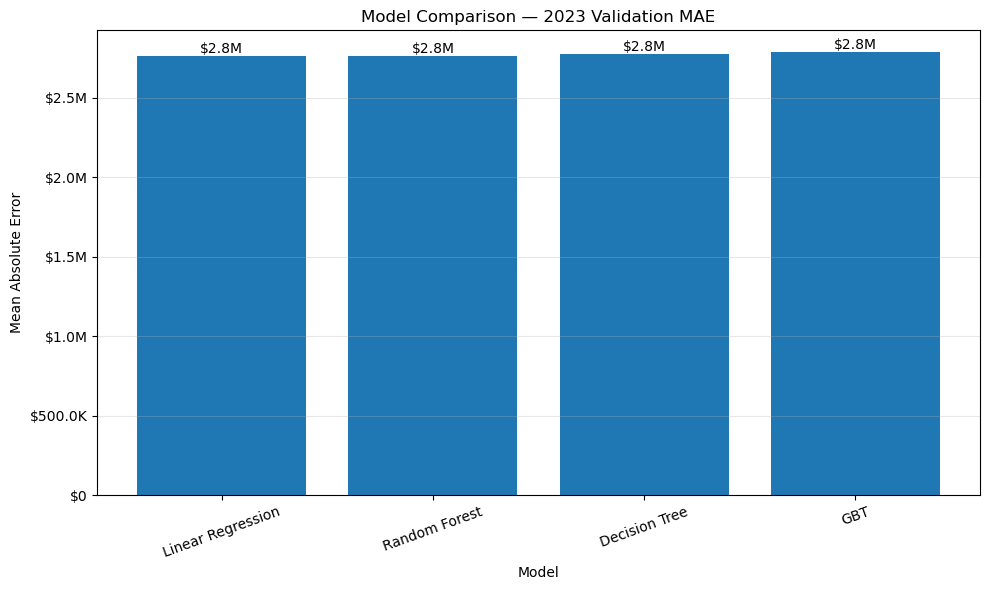

In [48]:
# Purpose: Evaluate regression performance using the configured error and goodness-of-fit metrics.
plt.figure(figsize=(10, 6))
bars = plt.bar(model_results_pd["model"], model_results_pd["mae"])
plt.title("Model Comparison — 2023 Validation MAE")
plt.xlabel("Model"
)
plt.ylabel(
    "Mean Absolute Error"
)
plt.gca().yaxis.set_major_formatter(
    money_axis
)
plt.xticks(
    rotation=20
)
plt.grid(
    axis="y",
    alpha=0.3
)
for bar, value in zip(
    bars,
    model_results_pd["mae"]
):
    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,
        bar.get_height(),
        money_formatter(
            value,
            None
        ),
        ha="center",
        va="bottom"
    )
plt.tight_layout()
plt.show()


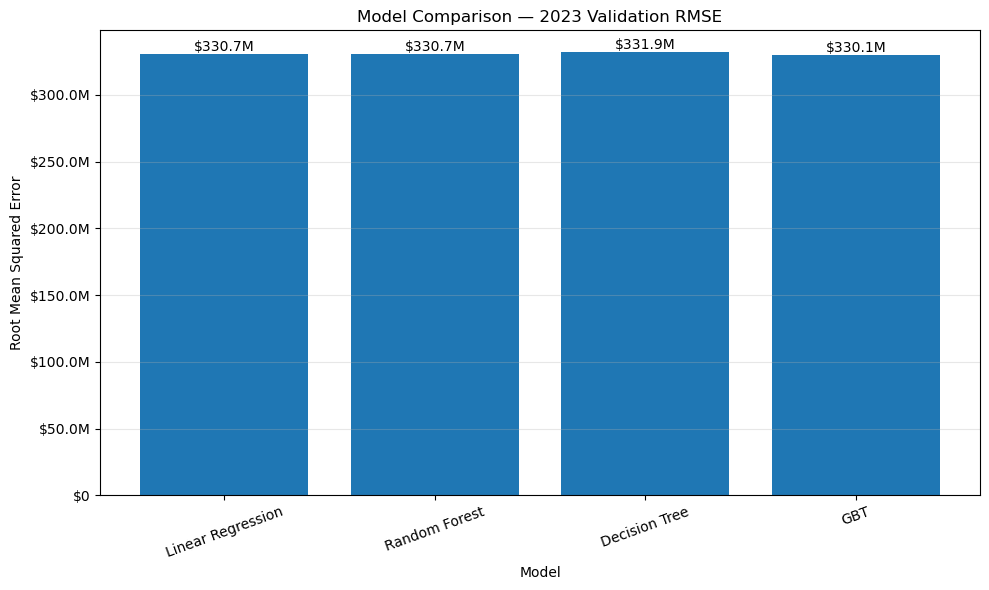

In [49]:
# Purpose: Evaluate regression performance using the configured error and goodness-of-fit metrics.
plt.figure(figsize=(10, 6))
bars = plt.bar(model_results_pd["model"], model_results_pd["rmse"])
plt.title("Model Comparison — 2023 Validation RMSE")
plt.xlabel("Model"
)
plt.ylabel(
    "Root Mean Squared Error"
)
plt.gca().yaxis.set_major_formatter(
    money_axis
)
plt.xticks(
    rotation=20
)
plt.grid(
    axis="y",
    alpha=0.3
)
for bar, value in zip(
    bars,
    model_results_pd["rmse"]
):
    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,
        bar.get_height(),
        money_formatter(
            value,
            None
        ),
        ha="center",
        va="bottom"
    )
plt.tight_layout()
plt.show()


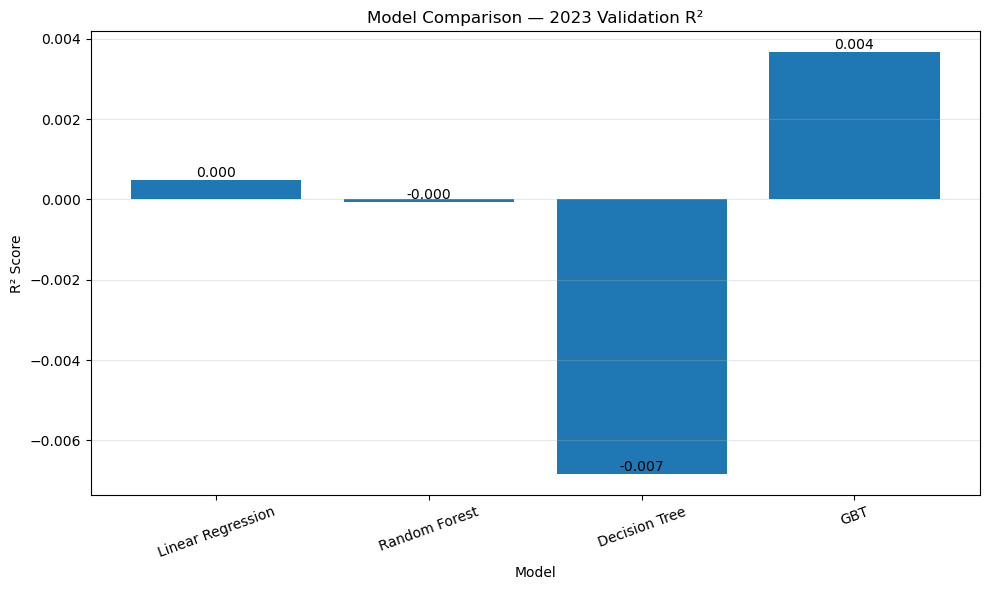

In [50]:
# Purpose: Evaluate regression performance using the configured error and goodness-of-fit metrics.
plt.figure(figsize=(10, 6))
bars = plt.bar(model_results_pd["model"], model_results_pd["r2"])
plt.title("Model Comparison — 2023 Validation R²")
plt.xlabel("Model"
)
plt.ylabel(
    "R² Score"
)
plt.xticks(
    rotation=20
)
plt.grid(
    axis="y",
    alpha=0.3
)
for bar, value in zip(
    bars,
    model_results_pd["r2"]
):
    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )
plt.tight_layout()
plt.show()


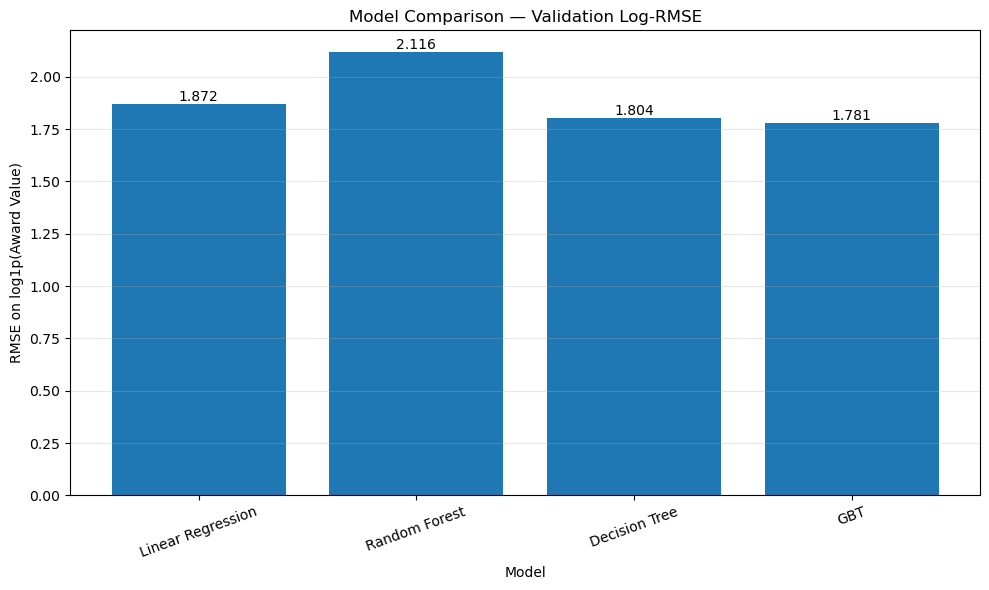

In [51]:
# Purpose: Evaluate regression performance using the configured error and goodness-of-fit metrics.
plt.figure(figsize=(10, 6))
bars = plt.bar(model_results_pd["model"], model_results_pd["log_rmse"])
plt.title("Model Comparison — Validation Log-RMSE")
plt.xlabel("Model"
)
plt.ylabel(
    "RMSE on log1p(Award Value)"
)
plt.xticks(
    rotation=20
)
plt.grid(
    axis="y",
    alpha=0.3
)
for bar, value in zip(
    bars,
    model_results_pd["log_rmse"]
):
    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )
plt.tight_layout()
plt.show()


## 17. Percentage-tolerance accuracy for all models


In [52]:
# Purpose: Define `award_value_accuracy_stats` to encapsulate the `award_value_accuracy_stats` processing logic for reuse.
def award_value_accuracy_stats(predictions):
    positive_actual = (predictions.filter(F.col("award_value_label") > 0)
        .withColumn(
            "absolute_percentage_error",
            F.abs(
                F.col(
                    "prediction_original"
                )
                -
                F.col(
                    "award_value_label"
                )
            )
            /
            F.col(
                "award_value_label"
            )
        )
    )
    stats = (
        positive_actual
        .agg(
            F.count("*")
            .alias("total_positive"),
            F.sum(
                F.when(
                    F.col(
                        "absolute_percentage_error"
                    ) <= 0.10,
                    1
                ).otherwise(0)
            )
            .alias("within_10"),
            F.sum(
                F.when(
                    F.col(
                        "absolute_percentage_error"
                    ) <= 0.25,
                    1
                ).otherwise(0)
            )
            .alias("within_25"),
            F.sum(
                F.when(
                    F.col(
                        "absolute_percentage_error"
                    ) <= 0.50,
                    1
                ).otherwise(0)
            )
            .alias("within_50")
        )
        .first()
    )
    total = (
        stats["total_positive"]
    )
    return {
        "total_positive":
            total,
        "within_10":
            stats["within_10"],
        "within_25":
            stats["within_25"],
        "within_50":
            stats["within_50"],
        "within_10_pct":
            stats["within_10"]
            / total
            * 100,
        "within_25_pct":
            stats["within_25"]
            / total
            * 100,
        "within_50_pct":
            stats["within_50"]
            / total
            * 100
    }


In [53]:
# Purpose: Display the resulting Spark rows or summary table for validation and interpretation.
award_accuracy = {}
for (model_name, predictions) in validation_predictions.items():
    award_accuracy[model_name] = (award_value_accuracy_stats(predictions)
    )
accuracy_results = (
    spark.createDataFrame(
        [
            (
                model_name,
                stats[
                    "total_positive"
                ],
                stats[
                    "within_10"
                ],
                stats[
                    "within_25"
                ],
                stats[
                    "within_50"
                ],
                stats[
                    "within_10_pct"
                ],
                stats[
                    "within_25_pct"
                ],
                stats[
                    "within_50_pct"
                ]
            )
            for (
                model_name,
                stats
            )
            in award_accuracy.items()
        ],
        [
            "model",
            "total_positive_actuals",
            "within_10_count",
            "within_25_count",
            "within_50_count",
            "within_10_pct",
            "within_25_pct",
            "within_50_pct"
        ]
    )
)
accuracy_results.show(
    truncate=False
)


+-----------------+----------------------+---------------+---------------+---------------+------------------+------------------+------------------+
|model            |total_positive_actuals|within_10_count|within_25_count|within_50_count|within_10_pct     |within_25_pct     |within_50_pct     |
+-----------------+----------------------+---------------+---------------+---------------+------------------+------------------+------------------+
|Linear Regression|5754848               |292065         |728803         |1510019        |5.075112322688627 |12.66415724620355 |26.239077035570705|
|Decision Tree    |5754848               |316064         |788412         |1616487        |5.4921346315315365|13.699962188401848|28.089134587047305|
|Random Forest    |5754848               |254393         |640463         |1330021        |4.420499029687665 |11.129103670505286|23.11131414765429 |
|GBT              |5754848               |311574         |778319         |1616857        |5.414113457036572 |13.

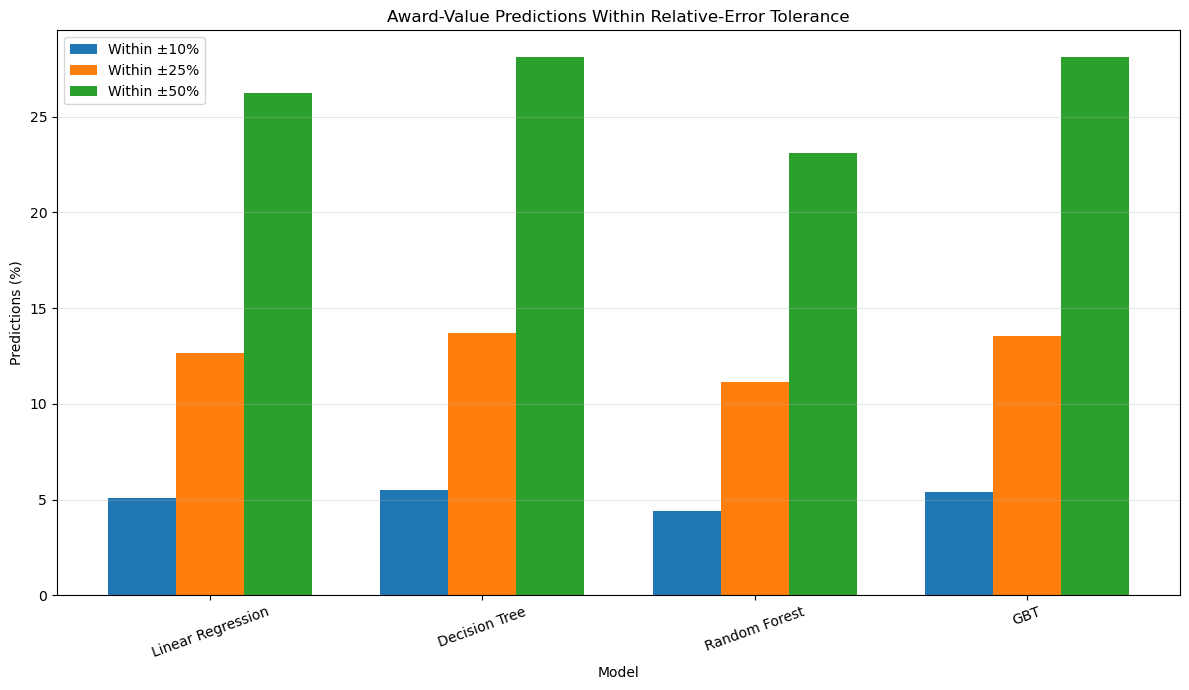

In [54]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
accuracy_pd = (accuracy_results.toPandas())
models = (accuracy_pd["model"])
x = np.arange(len(models))
width = 0.25
plt.figure(figsize=(12, 7)
)
plt.bar(
    x - width,
    accuracy_pd[
        "within_10_pct"
    ],
    width,
    label="Within ±10%"
)
plt.bar(
    x,
    accuracy_pd[
        "within_25_pct"
    ],
    width,
    label="Within ±25%"
)
plt.bar(
    x + width,
    accuracy_pd[
        "within_50_pct"
    ],
    width,
    label="Within ±50%"
)
plt.xticks(
    x,
    models,
    rotation=20
)
plt.ylabel(
    "Predictions (%)"
)
plt.xlabel(
    "Model"
)
plt.title(
    "Award-Value Predictions Within Relative-Error Tolerance"
)
plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)
plt.tight_layout()
plt.show()


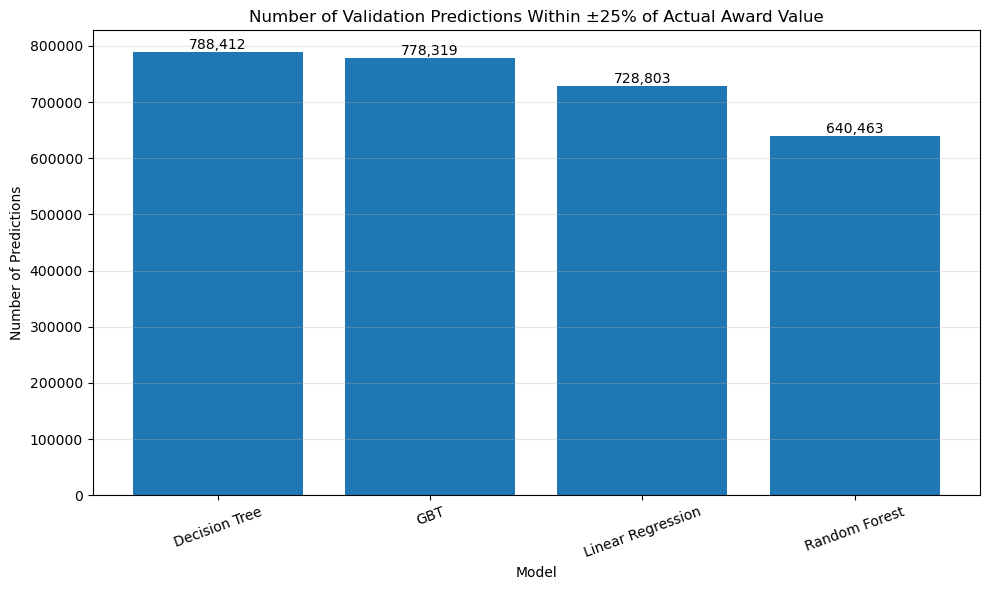

In [55]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
# Count-based equivalent of the offers notebook's
# "number of correct predictions" chart.
correct_count_pd = (accuracy_pd[["model", "within_25_count"]].sort_values("within_25_count",
        ascending=False
    )
)
plt.figure(
    figsize=(10, 6)
)
bars = plt.bar(
    correct_count_pd["model"],
    correct_count_pd[
        "within_25_count"
    ]
)
plt.title(
    "Number of Validation Predictions Within ±25% of Actual Award Value"
)
plt.xlabel(
    "Model"
)
plt.ylabel(
    "Number of Predictions"
)
plt.xticks(
    rotation=20
)
plt.ticklabel_format(
    style="plain",
    axis="y"
)
plt.grid(
    axis="y",
    alpha=0.3
)
for bar, value in zip(
    bars,
    correct_count_pd[
        "within_25_count"
    ]
):
    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom"
    )
plt.tight_layout()
plt.show()


## 18. Actual vs predicted plots — every model


In [56]:
# Purpose: Define `collect_prediction_sample` to encapsulate the `collect_prediction_sample` processing logic for reuse.
def collect_prediction_sample(predictions, fraction=0.01, limit=10000):
    return (predictions.select(F.col("award_value_label"
            ).alias(
                "actual"
            ),
            F.col(
                "prediction_original"
            ).alias(
                "predicted"
            )
        )
        .filter(
            F.col(
                "actual"
            ).isNotNull()
            &
            F.col(
                "predicted"
            ).isNotNull()
            &
            (
                F.col(
                    "actual"
                ) > 0
            )
            &
            (
                F.col(
                    "predicted"
                ) > 0
            )
        )
        .sample(
            False,
            fraction,
            seed=42
        )
        .limit(
            limit
        )
        .toPandas()
    )


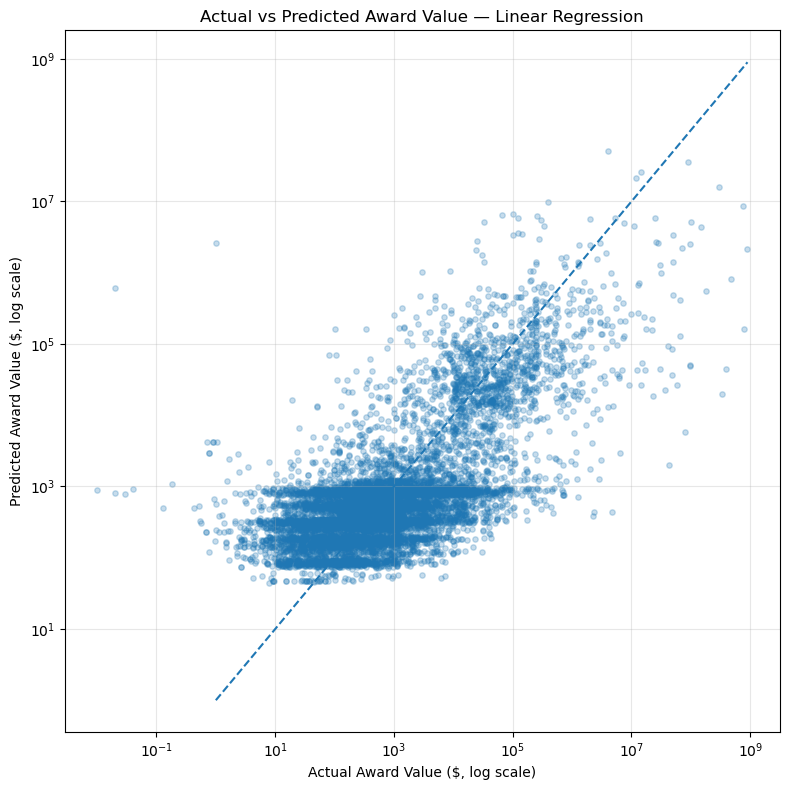

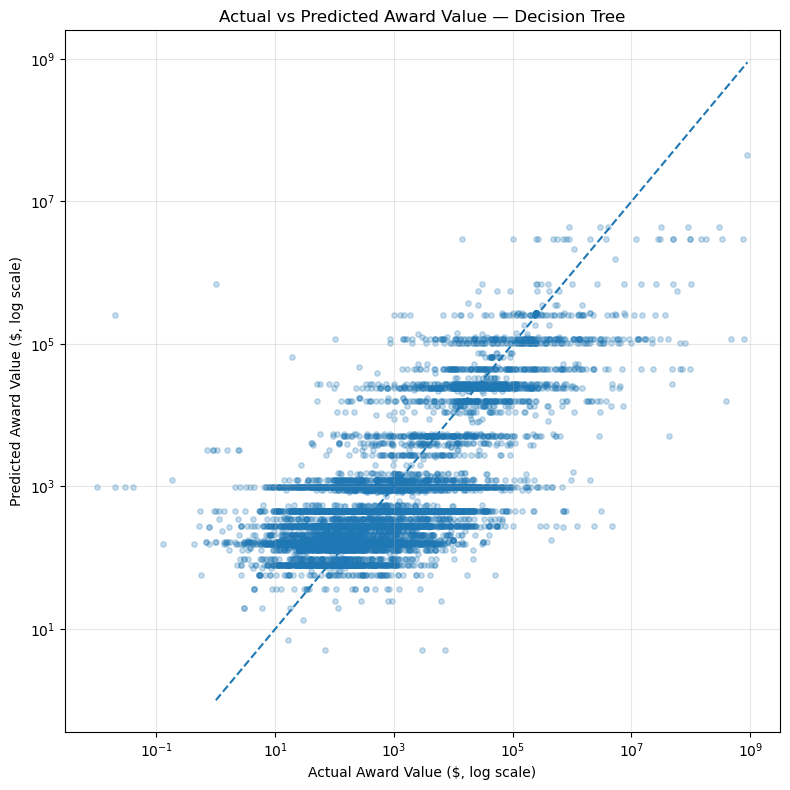

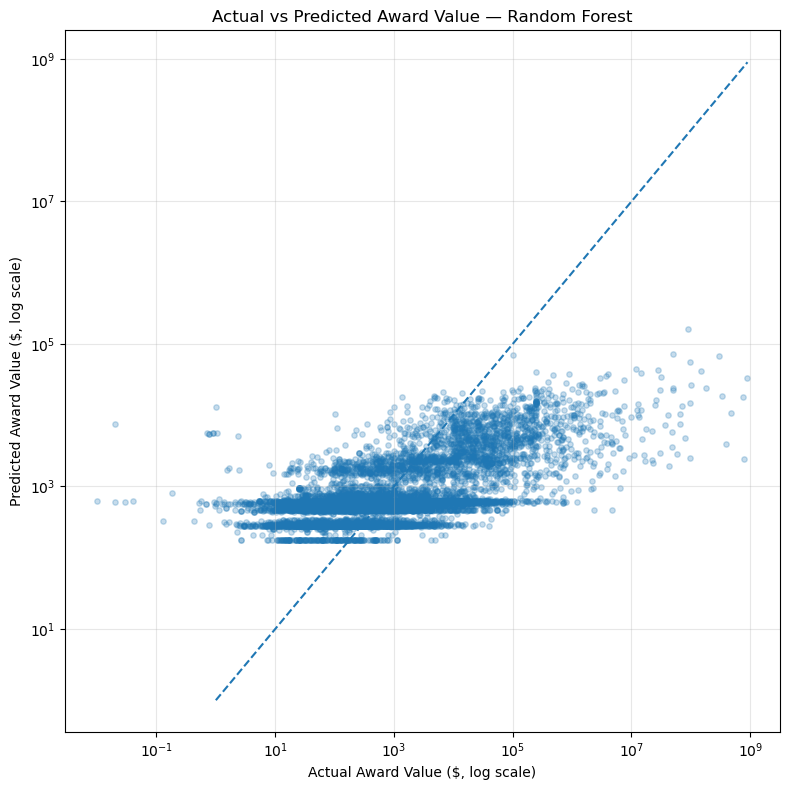

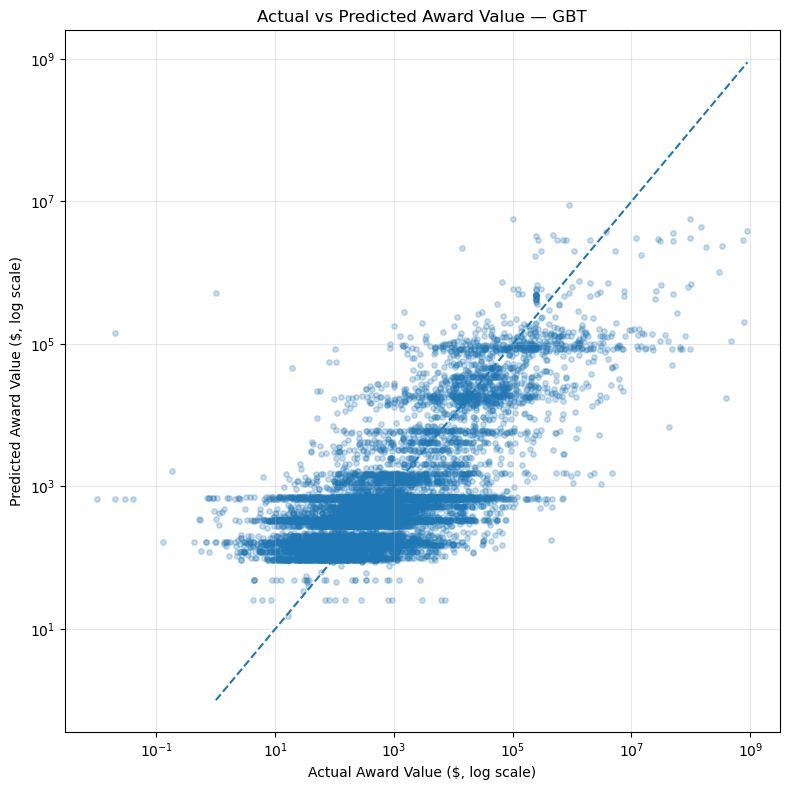

In [57]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
prediction_samples = {}
for (model_name, predictions) in validation_predictions.items():
    sample_pd = (collect_prediction_sample(predictions))
    prediction_samples[model_name
    ] = sample_pd
    plt.figure(
        figsize=(8, 8)
    )
    plt.scatter(
        sample_pd["actual"],
        sample_pd["predicted"],
        alpha=0.25,
        s=15
    )
    min_value = max(
        min(
            sample_pd["actual"].min(),
            sample_pd["predicted"].min()
        ),
        1.0
    )
    max_value = max(
        sample_pd["actual"].max(),
        sample_pd["predicted"].max()
    )
    plt.plot(
        [
            min_value,
            max_value
        ],
        [
            min_value,
            max_value
        ],
        linestyle="--"
    )
    # Award values are highly skewed,
    # so log axes make the relationship readable.
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(
        "Actual Award Value ($, log scale)"
    )
    plt.ylabel(
        "Predicted Award Value ($, log scale)"
    )
    plt.title(
        f"Actual vs Predicted Award Value — "
        f"{model_name}"
    )
    plt.grid(
        alpha=0.3
    )
    plt.tight_layout()
    plt.show()


## 19. Prediction-error distributions — every model


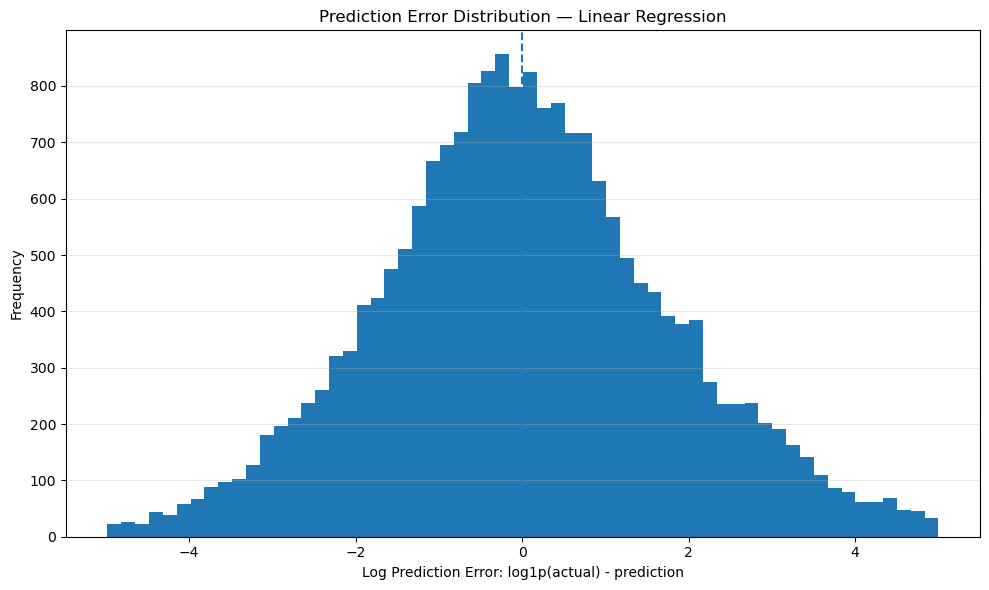

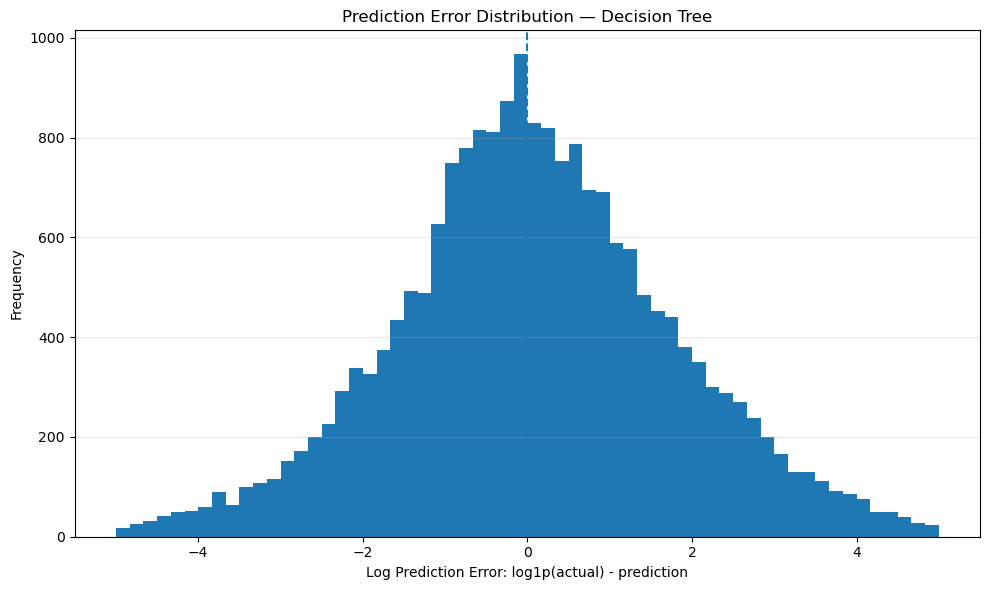

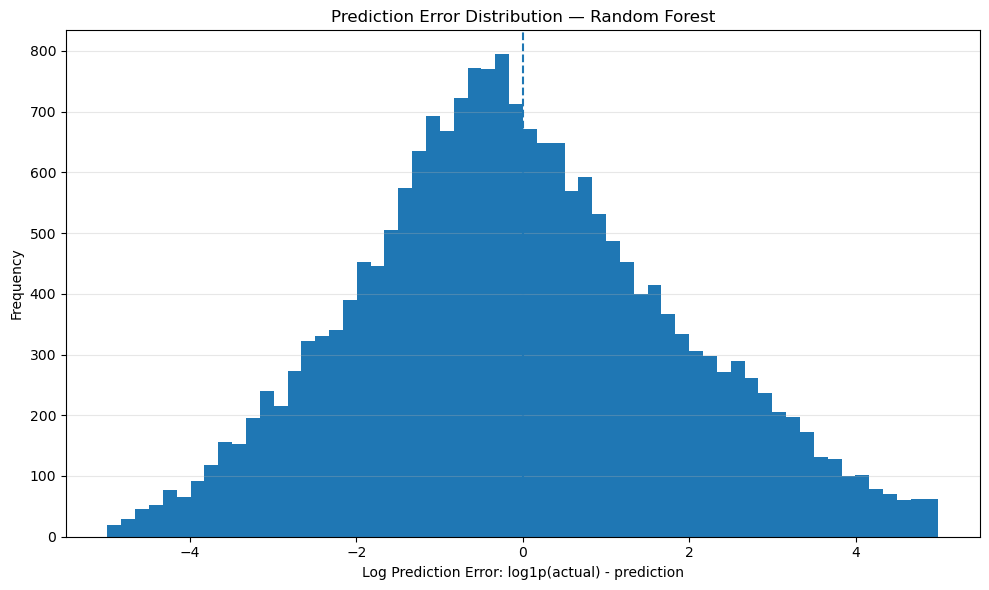

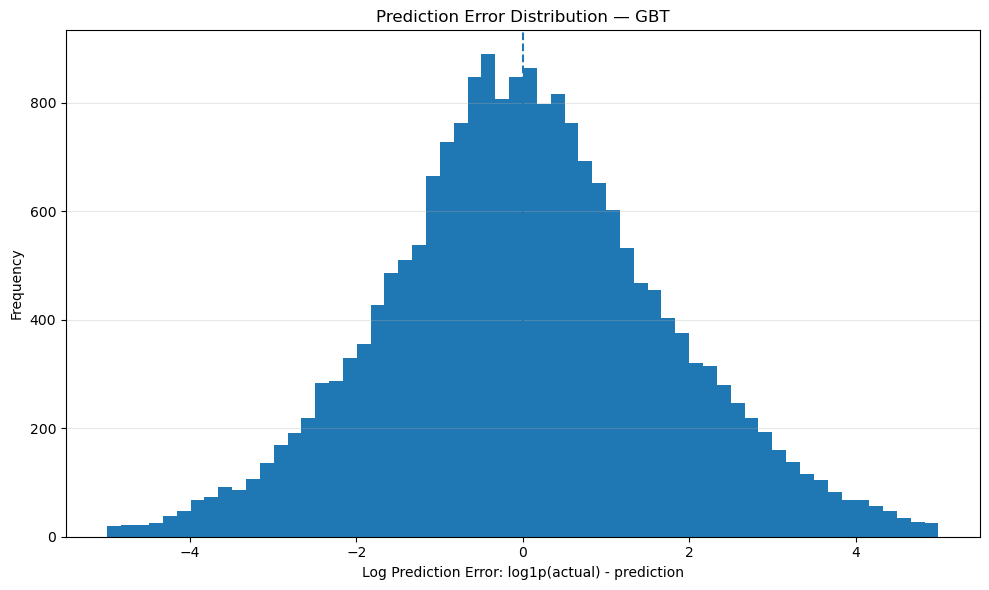

In [58]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
for (model_name, predictions) in validation_predictions.items():
    # Log-space residual:
    # log1p(actual) - model prediction.
    # This is much more interpretable for a highly skewed
    # monetary target than a raw-dollar histogram dominated
    # by a few extreme contracts.
    error_pd = (predictions.select((F.col("label") -
                F.col("prediction")
            ).alias(
                "log_error"
            )
        )
        .filter(
            F.col(
                "log_error"
            ).isNotNull()
        )
        .filter(
            F.abs(
                F.col(
                    "log_error"
                )
            ) <= 5
        )
        .sample(
            False,
            0.02,
            seed=42
        )
        .limit(
            20000
        )
        .toPandas()
    )
    plt.figure(
        figsize=(10, 6)
    )
    plt.hist(
        error_pd[
            "log_error"
        ],
        bins=60
    )
    plt.axvline(
        0,
        linestyle="--"
    )
    plt.xlabel(
        "Log Prediction Error: log1p(actual) - prediction"
    )
    plt.ylabel(
        "Frequency"
    )
    plt.title(
        f"Prediction Error Distribution — "
        f"{model_name}"
    )
    plt.grid(
        axis="y",
        alpha=0.3
    )
    plt.tight_layout()
    plt.show()


## 20. Extract feature names from Spark ML metadata


In [69]:
# Purpose: Define `clean_feature_name` to encapsulate the `clean_feature_name` processing logic for reuse.
# ============================================================
# Extract REAL feature names from features_raw metadata
# ============================================================
feature_probe = (award_feature_model.transform(award_train.limit(1)))
feature_metadata = (feature_probe.schema["features_raw"].metadata
)
attrs = (
    feature_metadata
    .get(
        "ml_attr",
        {}
    )
    .get(
        "attrs",
        {}
    )
)
raw_feature_names = {}
for attr_type in attrs:
    for item in attrs[attr_type]:
        raw_feature_names[
            int(item["idx"])
        ] = (
            item["name"]
        )
# ============================================================
# Convert Spark-generated names into readable names
# ============================================================
def clean_feature_name(
    raw_name
):
    # One-hot encoded categorical features
    for column in CATEGORICAL_FEATURES:
        prefix = (
            f"{column}_ohe_"
        )
        if raw_name.startswith(
            prefix
        ):
            category = (
                raw_name[
                    len(prefix):
                ]
            )
            return (
                f"{column} = {category}"
            )
    # Imputed numeric features
    for column in NUMERIC_FEATURES:
        if raw_name == (
            f"{column}_imp"
        ):
            return column
    return raw_name
feature_names = {
    index:
        clean_feature_name(
            name
        )
    for (
        index,
        name
    )
    in raw_feature_names.items()
}
print(
    "Number of named features:",
    len(feature_names)
)
print(
    "Model feature count:",
    rf_model.numFeatures
)

Number of named features: 1468
Model feature count: 1468


In [70]:
# Purpose: Map model feature indices to their original names and inspect feature importance.
expected_features = (rf_model.numFeatures)
missing_indices = [i for i in range(expected_features) if i not in feature_names]
print(
    "Expected features:",
    expected_features
)
print(
    "Mapped features:",
    len(feature_names)
)
print(
    "Missing mappings:",
    len(missing_indices)
)
if missing_indices:
    print(
        "Missing indices:",
        missing_indices[:20]
    )
else:
    print(
        "SUCCESS: all feature indices mapped correctly."
    )

Expected features: 1468
Mapped features: 1468
Missing mappings: 0
SUCCESS: all feature indices mapped correctly.


In [71]:
# Purpose: Map model feature indices to their original names and inspect feature importance.
feature_mapping_pd = (pd.DataFrame([{"feature_index": index, "feature_name": feature_names[index
                    ]
            }
            for index in sorted(
                feature_names
            )
        ]
    )
)
display(
    feature_mapping_pd.head(
        50
    )
)

,feature_index,feature_name
0,0,award_type = IDC
1,1,award_type = BPA
2,2,award_type = __UNKNOWN__
3,3,award_type = B
4,4,award_type = FSS
5,5,award_type = C
6,6,award_type = A
7,7,award_type = BOA
8,8,award_type = D
9,9,award_type = GWAC


## 21. Tree feature importance — Decision Tree, Random Forest and GBT


In [72]:
# Purpose: Define `get_feature_importance_df` to encapsulate the `get_feature_importance_df` processing logic for reuse.
def get_feature_importance_df(model, feature_names, top_n=20):
    importance_vector = (model.featureImportances)
    rows = []
    for i in range(importance_vector.size):
        importance = float(
            importance_vector[i]
        )
        if importance > 0:
            rows.append(
                {
                    "feature_index":
                        i,
                    "feature":
                        feature_names[i],
                    "importance":
                        importance
                }
            )
    importance_pd = (
        pd.DataFrame(
            rows
        )
        .sort_values(
            "importance",
            ascending=False
        )
        .head(
            top_n
        )
    )
    return importance_pd

,feature_index,feature,importance
105,1465,duration_days,0.460129
19,135,awarding_subagency_code = 97AS,0.125344
98,1026,pop_country = USA,0.110178
20,136,awarding_subagency_code = 4732,0.081446
99,1028,pop_country = __UNKNOWN__,0.039346
31,412,naics2 = 33,0.019168
56,461,psc2 = 23,0.018516
25,143,awarding_subagency_code = 97AK,0.016792
12,25,solicitation_procedures = SIMPLIFIED ACQUISITION,0.015370
71,620,recipient_state = CA,0.010684


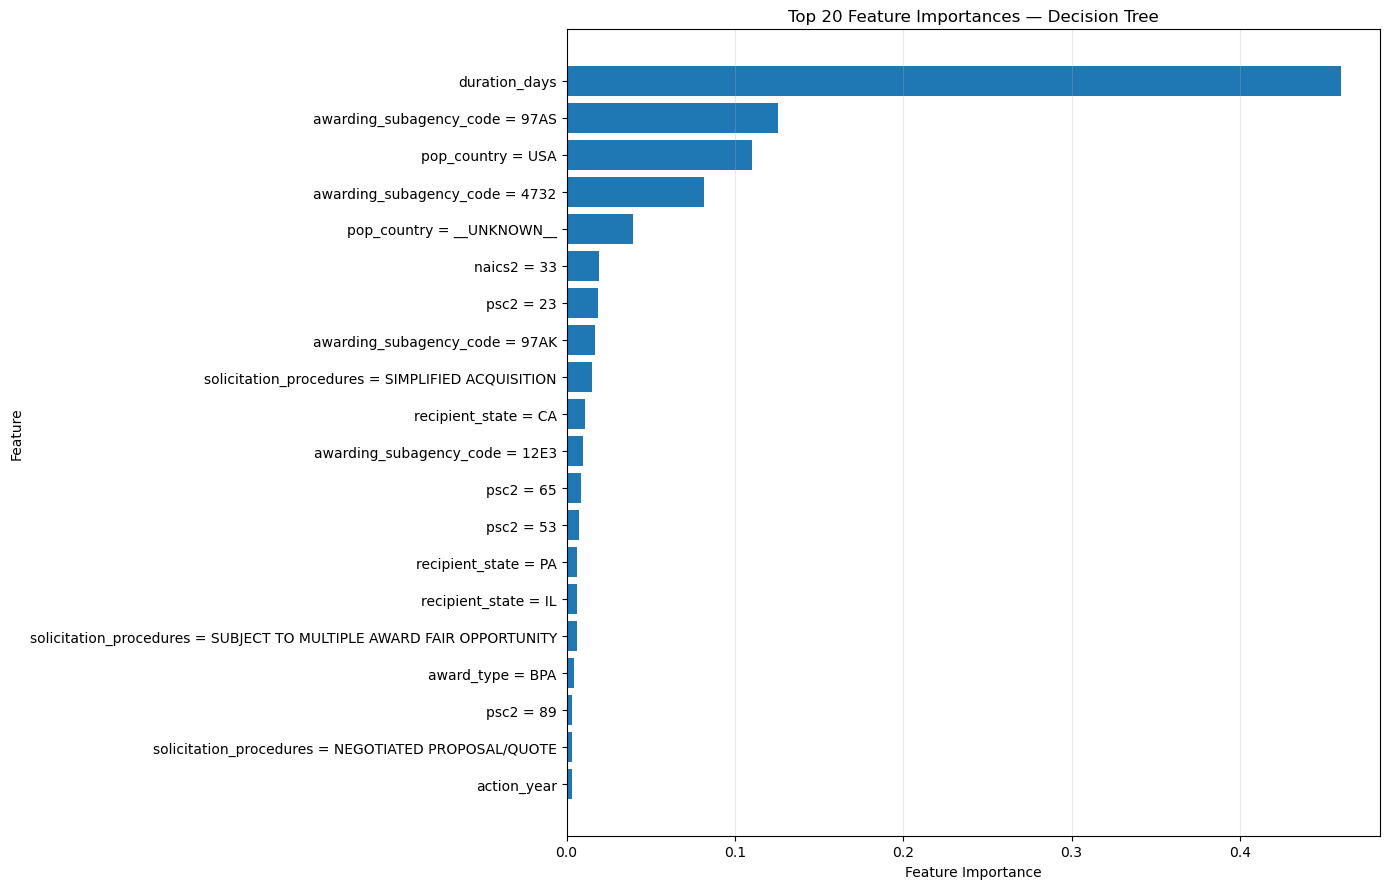

,feature_index,feature,importance
447,1465,duration_days,0.095388
124,312,funding_agency_name = GENERAL SERVICES ADMINIS...,0.066055
27,34,type_of_set_aside = __UNKNOWN__,0.060496
408,1026,pop_country = USA,0.049254
60,136,awarding_subagency_code = 4732,0.047860
153,416,naics2 = 54,0.036335
410,1028,pop_country = __UNKNOWN__,0.022956
39,62,awarding_agency_code = 047,0.022711
2,2,award_type = __UNKNOWN__,0.022169
40,63,awarding_agency_code = 012,0.022026


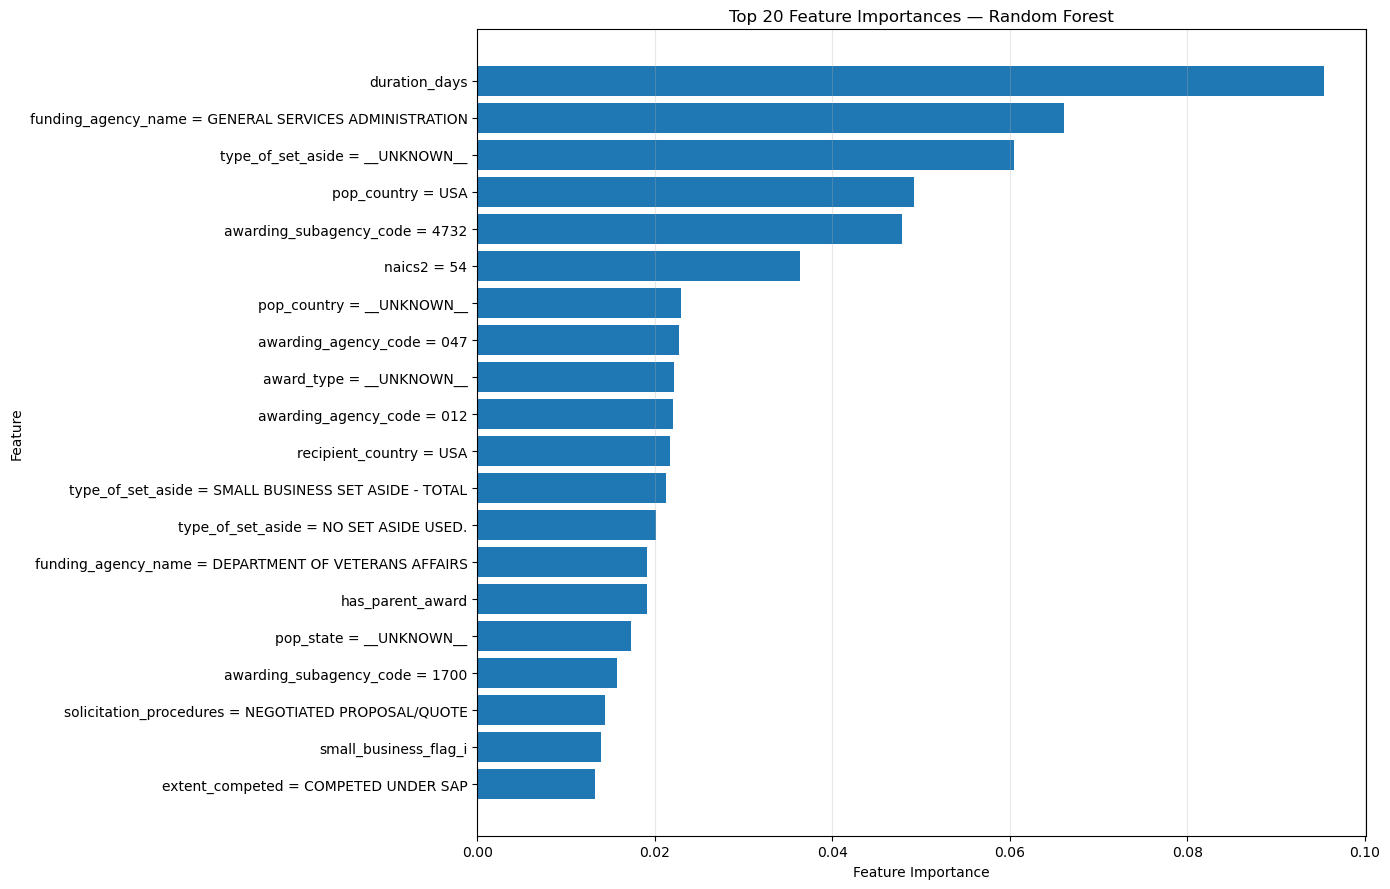

,feature_index,feature,importance
228,1465,duration_days,0.279142
42,135,awarding_subagency_code = 97AS,0.055986
213,1026,pop_country = USA,0.043514
103,438,psc2 = 65,0.037775
187,966,pop_state = PA,0.035520
43,136,awarding_subagency_code = 4732,0.035451
107,442,psc2 = 91,0.028121
87,413,naics2 = 42,0.025031
112,447,psc2 = 68,0.024265
10,11,extent_competed = FULL AND OPEN COMPETITION,0.021630


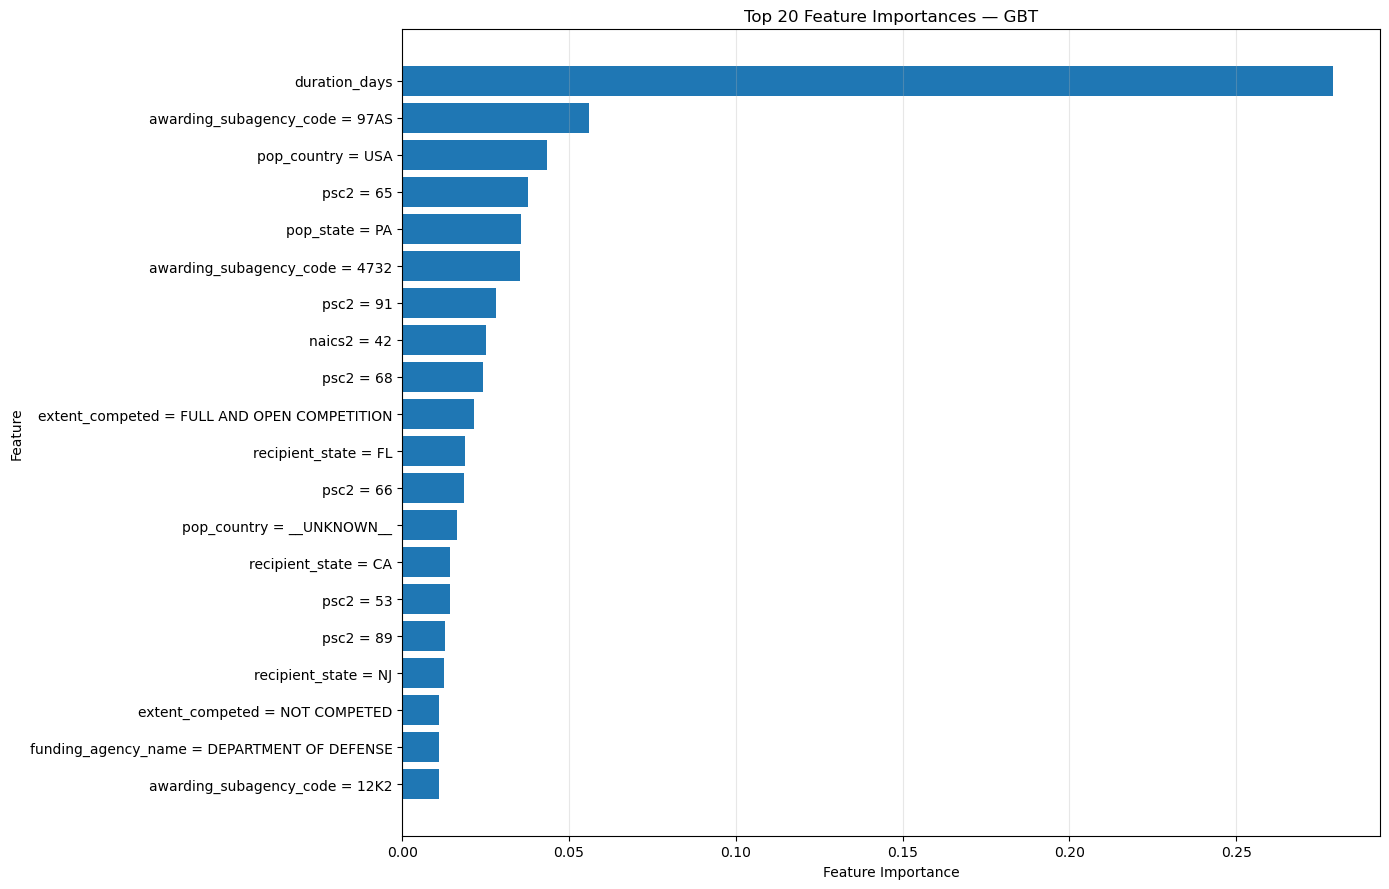

In [73]:
# Purpose: Map model feature indices to their original names and inspect feature importance.
tree_models = {"Decision Tree": dt_model, "Random Forest": rf_model, "GBT": gbt_model}
tree_importance_tables = {}
for (model_name,
    model
) in tree_models.items():
    importance_pd = (
        get_feature_importance_df(
            model,
            feature_names,
            top_n=20
        )
    )
    tree_importance_tables[
        model_name
    ] = (
        importance_pd
    )
    # Show feature table
    display(
        importance_pd
    )
    # Plot
    plt.figure(
        figsize=(14, 9)
    )
    plt.barh(
        importance_pd[
            "feature"
        ][::-1],
        importance_pd[
            "importance"
        ][::-1]
    )
    plt.xlabel(
        "Feature Importance"
    )
    plt.ylabel(
        "Feature"
    )
    plt.title(
        f"Top 20 Feature Importances — "
        f"{model_name}"
    )
    plt.grid(
        axis="x",
        alpha=0.3
    )
    plt.tight_layout()
    plt.show()

## 22. Linear Regression coefficient-magnitude visual

Linear Regression does not expose tree-style `featureImportances`. The equivalent diagnostic is the magnitude of its learned coefficients.

Because the feature vector is standardized by the shared preprocessing pipeline, ranking coefficients by absolute magnitude is useful for model interpretation. The sign is preserved in the table.


In [74]:
# Purpose: Map model feature indices to their original names and inspect feature importance.
lr_rows = []
for (i, coefficient) in enumerate(lr_model.coefficients):
    coefficient = float(coefficient)
    lr_rows.append({
            "feature_index":
                i,
            "feature":
                feature_names[i],
            "coefficient":
                coefficient,
            "abs_coefficient":
                abs(
                    coefficient
                )
        }
    )
lr_coefficients_pd = (
    pd.DataFrame(
        lr_rows
    )
    .sort_values(
        "abs_coefficient",
        ascending=False
    )
    .head(
        20
    )
)
display(
    lr_coefficients_pd
)

,feature_index,feature,coefficient,abs_coefficient
461,461,psc2 = 23,0.310353,0.310353
1028,1028,pop_country = __UNKNOWN__,0.291148,0.291148
139,139,awarding_subagency_code = 2100,0.276614,0.276614
312,312,funding_agency_name = GENERAL SERVICES ADMINIS...,-0.252258,0.252258
138,138,awarding_subagency_code = 1700,0.248160,0.248160
142,142,awarding_subagency_code = 5700,0.246709,0.246709
1465,1465,duration_days,0.236183,0.236183
136,136,awarding_subagency_code = 4732,-0.186321,0.186321
444,444,psc2 = 53,-0.186080,0.186080
135,135,awarding_subagency_code = 97AS,-0.176285,0.176285


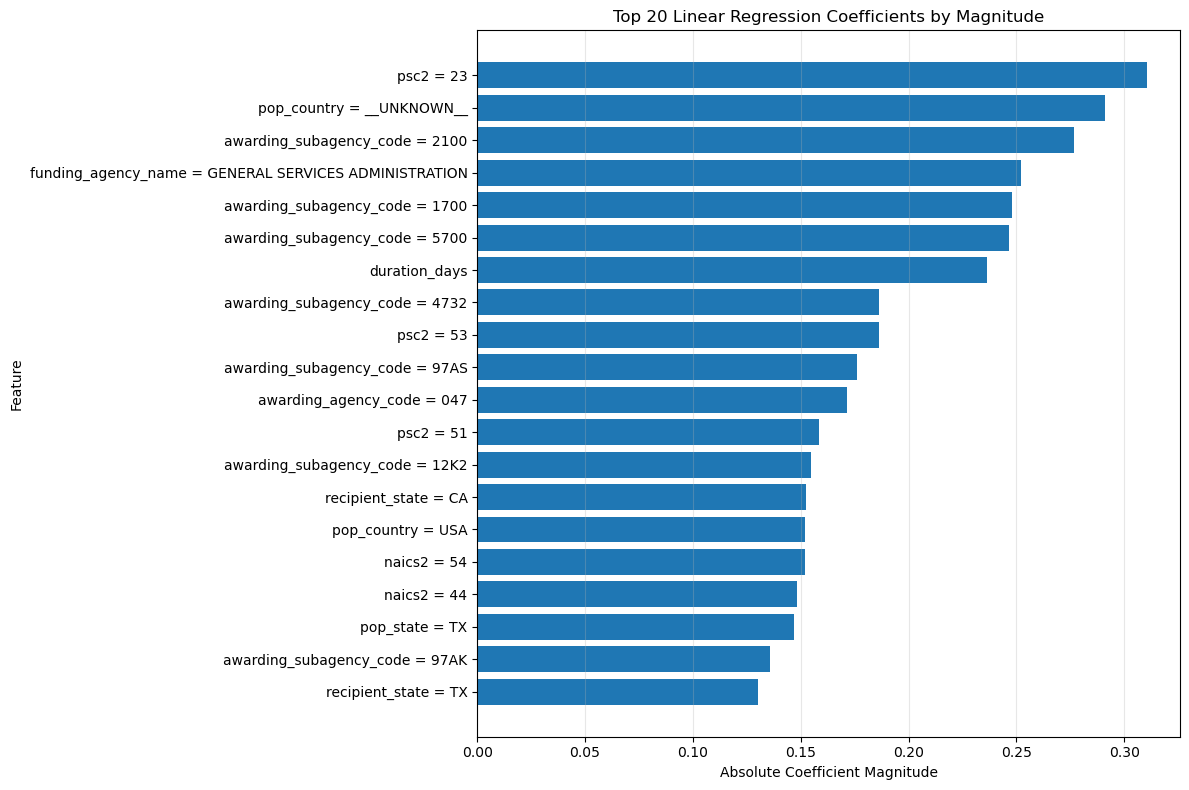

In [75]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
plt.figure(figsize=(12, 8))
plt.barh(lr_coefficients_pd["feature"][::-1], lr_coefficients_pd["abs_coefficient"][::-1]
)
plt.xlabel(
    "Absolute Coefficient Magnitude"
)
plt.ylabel(
    "Feature"
)
plt.title(
    "Top 20 Linear Regression Coefficients by Magnitude"
)
plt.grid(
    axis="x",
    alpha=0.3
)
plt.tight_layout()
plt.show()


In [77]:
# Purpose: Define `get_original_feature` to encapsulate the `get_original_feature` processing logic for reuse.
def get_original_feature(feature_name):
    if " = " in feature_name:
        return (feature_name.split(" = ", 1)[0])
    return feature_name

In [78]:
# Purpose: Aggregate the Spark data to produce summary statistics for this analysis.
rf_importance_pd = (get_feature_importance_df(rf_model, feature_names, top_n=rf_model.numFeatures))
rf_importance_pd["original_feature"] = (
    rf_importance_pd[
        "feature"
    ]
    .apply(
        get_original_feature
    )
)
rf_grouped_pd = (
    rf_importance_pd
    .groupby(
        "original_feature",
        as_index=False
    )
    ["importance"]
    .sum()
    .sort_values(
        "importance",
        ascending=False
    )
)
display(
    rf_grouped_pd
)

,original_feature,importance
5,awarding_subagency_code,0.117803
9,funding_agency_name,0.105404
19,type_of_set_aside,0.102273
6,duration_days,0.095388
4,awarding_agency_code,0.082975
11,naics2,0.079362
12,pop_country,0.076731
14,psc2,0.072513
3,award_type,0.047687
13,pop_state,0.042672


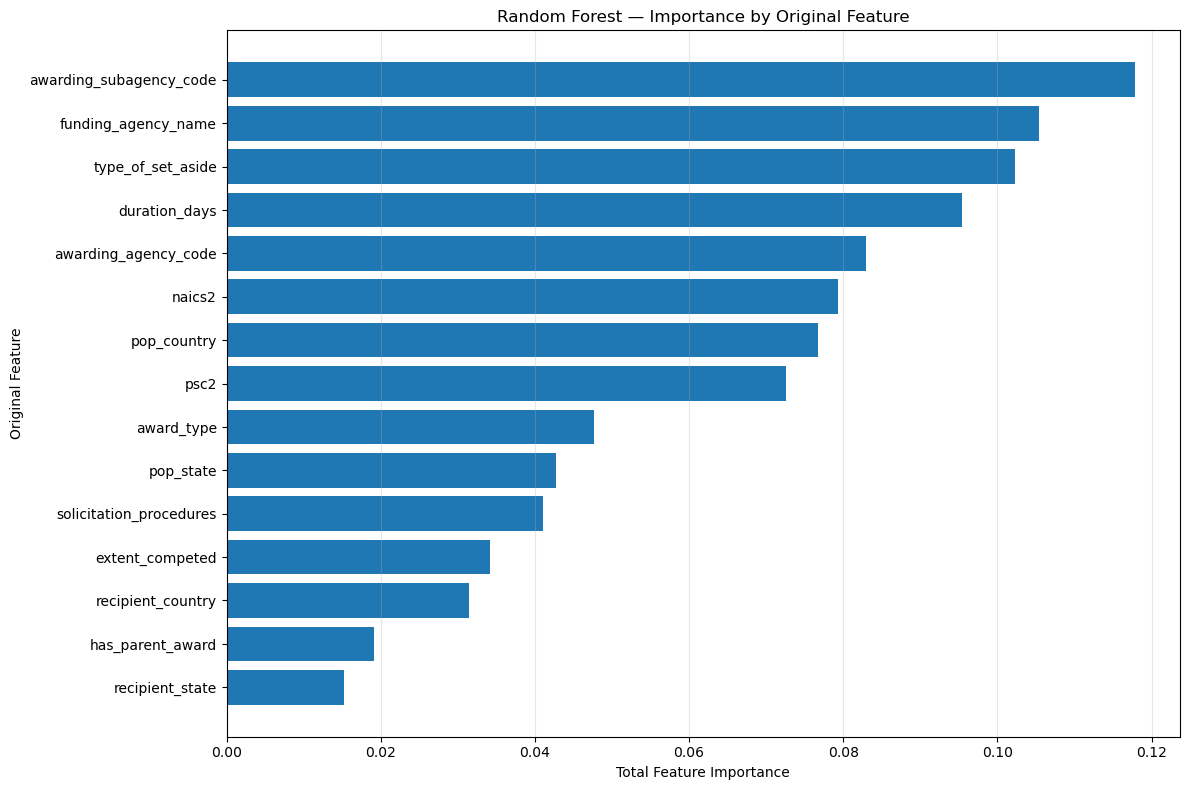

In [79]:
# Purpose: Visualize the computed Big Data statistics or model results for interpretation.
top_rf_grouped = (rf_grouped_pd.head(15))
plt.figure(figsize=(12, 8))
plt.barh(top_rf_grouped["original_feature"][::-1],
    top_rf_grouped[
        "importance"
    ][::-1]
)
plt.xlabel(
    "Total Feature Importance"
)
plt.ylabel(
    "Original Feature"
)
plt.title(
    "Random Forest — Importance by Original Feature"
)
plt.grid(
    axis="x",
    alpha=0.3
)
plt.tight_layout()
plt.show()

## 23. Combined evaluation summary


In [76]:
# Purpose: Evaluate regression performance using the configured error and goodness-of-fit metrics.
evaluation_summary = (model_results.join(accuracy_results, on="model", how="inner").select("model",
        F.round(
            "mae",
            2
        ).alias(
            "MAE"
        ),
        F.round(
            "rmse",
            2
        ).alias(
            "RMSE"
        ),
        F.round(
            "r2",
            4
        ).alias(
            "R2"
        ),
        F.round(
            "log_rmse",
            4
        ).alias(
            "Log_RMSE"
        ),
        F.round(
            "within_10_pct",
            2
        ).alias(
            "Within_10_Pct"
        ),
        F.round(
            "within_25_pct",
            2
        ).alias(
            "Within_25_Pct"
        ),
        F.round(
            "within_50_pct",
            2
        ).alias(
            "Within_50_Pct"
        ),
        "within_25_count"
    )
    .orderBy(
        F.asc("MAE")
    )
)
evaluation_summary.show(
    truncate=False
)


+-----------------+----------+--------------+-------+--------+-------------+-------------+-------------+---------------+
|model            |MAE       |RMSE          |R2     |Log_RMSE|Within_10_Pct|Within_25_Pct|Within_50_Pct|within_25_count|
+-----------------+----------+--------------+-------+--------+-------------+-------------+-------------+---------------+
|Linear Regression|2759525.33|3.3065172677E8|5.0E-4 |1.8718  |5.08         |12.66        |26.24        |728803         |
|Random Forest    |2763259.27|3.3074351905E8|-1.0E-4|2.1162  |4.42         |11.13        |23.11        |640463         |
|Decision Tree    |2772452.15|3.3186181947E8|-0.0068|1.8044  |5.49         |13.7         |28.09        |788412         |
|GBT              |2783919.16|3.3012633881E8|0.0037 |1.7813  |5.41         |13.52        |28.1         |778319         |
+-----------------+----------+--------------+-------+--------+-------------+-------------+-------------+---------------+



## 24. Save preprocessing, all models and evaluation outputs to GCS


In [41]:
# Purpose: Write the processed Big Data or trained model artifact to the configured GCS location.
lr_model.write() \
    .overwrite() \
    .save(f"{AWARD_MODEL_ROOT}/linear_regression")
dt_model.write() \
    .overwrite() \
    .save(f"{AWARD_MODEL_ROOT}/decision_tree")
rf_model.write() \
    .overwrite() \
    .save(f"{AWARD_MODEL_ROOT}/random_forest")

In [65]:
# Purpose: Write the processed Big Data or trained model artifact to the configured GCS location.
award_feature_model.write() \
    .overwrite() \
    .save(f"{AWARD_MODEL_ROOT}/preprocessor")
# lr_model.write() \
#     .overwrite() \
#     .save(
#         f"{AWARD_MODEL_ROOT}/linear_regression"
#     )
# dt_model.write() \
#     .overwrite() \
#     .save(
#         f"{AWARD_MODEL_ROOT}/decision_tree"
#     )
rf_model.write() \
    .overwrite() \
    .save(f"{AWARD_MODEL_ROOT}/random_forest")
gbt_model.write() \
    .overwrite() \
    .save(f"{AWARD_MODEL_ROOT}/gbt")
print("Saved all preprocessing and model artifacts.")


Saved all preprocessing and model artifacts.


In [66]:
# Purpose: Write the processed Big Data or trained model artifact to the configured GCS location.
(model_results.write.mode("overwrite").parquet(f"{AWARD_MODEL_ROOT}/" "validation_metrics"))
(
    evaluation_summary
    .write
    .mode("overwrite")
    .parquet(
        f"{AWARD_MODEL_ROOT}/"
        "evaluation_summary"
    )
)
(
    evaluation_summary
    .coalesce(1)
    .write
    .mode("overwrite")
    .option(
        "header",
        True
    )
    .csv(
        f"{AWARD_MODEL_ROOT}/"
        "evaluation_summary_csv"
    )
)


In [67]:
# Purpose: Evaluate regression performance using the configured error and goodness-of-fit metrics.
final_test_results = (spark.createDataFrame([(best_model_name, float(test_metrics["RMSE"]), float(
                    test_metrics["MAE"]
                ),
                float(
                    test_metrics["R2"]
                ),
                float(
                    test_metrics["Log_RMSE"]
                )
            )
        ],
        [
            "model",
            "rmse",
            "mae",
            "r2",
            "log_rmse"
        ]
    )
)
(
    final_test_results
    .write
    .mode("overwrite")
    .parquet(
        f"{AWARD_MODEL_ROOT}/"
        "final_test_metrics"
    )
)
final_test_results.show(
    truncate=False
)


+-----------------+--------------------+----------------+--------------------+------------------+
|model            |rmse                |mae             |r2                  |log_rmse          |
+-----------------+--------------------+----------------+--------------------+------------------+
|Linear Regression|1.4070194321592784E8|1589974.78000422|0.001626798331652246|1.9099295467328394|
+-----------------+--------------------+----------------+--------------------+------------------+



## 25. Cleanup cached DataFrames


In [68]:
# Purpose: Execute the code for the notebook section: 25. Cleanup cached DataFrames.
for predictions in (validation_predictions.values()):
    predictions.unpersist()
test_predictions.unpersist()
award_train_f.unpersist()
award_val_f.unpersist()
award_test_f.unpersist()
print("Cached DataFrames released.")


Cached DataFrames released.


# End

This notebook keeps the same project design as the offers model while making the evaluation appropriate for a continuous monetary target.

Recommended comparison criteria:
1. **2023 validation MAE** for primary model selection.
2. RMSE to show sensitivity to large errors.
3. R² for explained variance.
4. Log-RMSE to evaluate performance on the scale used for training.
5. Relative-error tolerance plots to show practical prediction accuracy across contracts of different sizes.
6. 2024 is used only after the best model is chosen from 2023.
